PERSONALISATION

In [19]:
%cd /content
!rm -rf breath_aac
!git clone https://github.com/naflanawas/breath_aac.git
%cd breath_aac
!git checkout main_dev


/content
Cloning into 'breath_aac'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 153 (delta 62), reused 118 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 645.51 KiB | 17.45 MiB/s, done.
Resolving deltas: 100% (62/62), done.
/content/breath_aac
Branch 'main_dev' set up to track remote branch 'main_dev' from 'origin'.
Switched to a new branch 'main_dev'


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
#!unzip -q "/content/drive/MyDrive/FYP_2025/Implementation/models.zip" -d /content/breath_aac/
#!ls models | head

!unzip -q "/content/drive/MyDrive/fyp/models.zip" -d /content/breath_aac/
!unzip -q "/content/drive/MyDrive/fyp/features.zip" -d /content/breath_aac/
!ls models | head
!ls features | head


ms_tcn_colab_1024.pt
ms_tcn_local_256.pt
mel_dd_subjectwise


In [21]:
import pandas as pd

SPLIT_CSV = "manifests/split_2c_subjectwise.csv"
K = 5

df = pd.read_csv(SPLIT_CSV)
test_df = df[df["split"] == "test"].copy()

# count samples per (subject, label)
counts = test_df.groupby(["subject_id", "label"]).size().unstack(fill_value=0)

# subjects that don't have enough for BOTH classes
bad = counts[(counts.min(axis=1) < K)]

print("Total test subjects:", counts.shape[0])
print(f"Subjects with < {K} samples in at least one class:", bad.shape[0])

# show a few
display(bad.head(20))


Total test subjects: 382
Subjects with < 5 samples in at least one class: 382


label,long,short
subject_id,,
05bieNLXPuaIWEVaX81EkbbjVrh1,1,1
0Js6ZUZQ9NUnu568Fh7B6mZ1R8o1,1,1
0c00ybTdnIRUTXeg20bZjJOzhKv1,1,1
0drfnqVwccT6UmgVLQEuyVglDC23,1,1
0eQAE4NgLUWYqAaMuWoO4XgIgvF2,1,1
0mkAUAbpROMIFjKpdFxlUnYTV262,1,1
0sIeyohqXMOGTqPA7RiiuyJ3AOt2,1,1
0zUxdfS5aoS6SiEoF1x6JXOk25B3,1,1
1B70um5alIc8VeCeJmosZsSuPTm2,1,1


In [8]:
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

from src.train.train_ms_tcn_2c import MSTCN, pick_device
from src.features.protonet import compute_prototypes, prototypical_predict


In [9]:
SPLIT_CSV = "manifests/split_2c_subjectwise.csv"
CKPT = "models/ms_tcn_colab_1024.pt"
MAX_LEN = 1024

K = 5
SEED = 7


In [10]:
df = pd.read_csv(SPLIT_CSV)

classes = sorted(df[df["split"] == "train"]["label"].unique())
c2i = {c:i for i,c in enumerate(classes)}
i2c = {i:c for c,i in c2i.items()}

print("Classes:", classes)


Classes: ['long', 'short']


In [12]:
device = pick_device()
print("Device:", device)

model = MSTCN(in_ch=3, n_classes=len(classes)).to(device)
model.load_state_dict(torch.load(CKPT, map_location=device), strict=False)
model.eval()

for p in model.parameters():
    p.requires_grad = False

print("Loaded checkpoint:", CKPT)


Device: cuda
Loaded checkpoint: models/ms_tcn_colab_1024.pt


In [13]:
def load_npy_as_tensor(path, max_len=1024):
    x = np.load(path)  # [3, 64, T]

    # CMVN (same as training)
    mean = x.mean(axis=(1,2), keepdims=True)
    std  = x.std(axis=(1,2), keepdims=True) + 1e-8
    x = (x - mean) / std

    T = x.shape[-1]
    if T < max_len:
        pad = np.zeros((x.shape[0], x.shape[1], max_len - T), dtype=x.dtype)
        x = np.concatenate([x, pad], axis=-1)
    elif T > max_len:
        x = x[:, :, :max_len]

    return torch.from_numpy(x).float()


In [14]:
def embed_paths(paths):
    X = torch.stack([load_npy_as_tensor(p, MAX_LEN) for p in paths], dim=0)
    X = X.to(device)

    with torch.no_grad():
        emb = model(X, return_embedding=True)

    return emb.cpu()


In [16]:
rng = np.random.default_rng(SEED)

all_true_global, all_pred_global = [], []
all_true_proto,  all_pred_proto  = [], []

per_subject_rows = []

subjects = sorted(test_df["subject_id"].unique())
print("Num test subjects:", len(subjects))

for sid in subjects:
    sdf = test_df[test_df["subject_id"] == sid]

    paths_long  = sdf[sdf["label"] == "long"]["filepath"].tolist()
    paths_short = sdf[sdf["label"] == "short"]["filepath"].tolist()

    # dynamic K per subject
    k_subj = min(K, len(paths_long), len(paths_short))
    if k_subj < 1:
        continue

    sup_long  = rng.choice(paths_long,  size=k_subj, replace=False).tolist()
    sup_short = rng.choice(paths_short, size=k_subj, replace=False).tolist()

    support_paths  = sup_long + sup_short
    support_labels = torch.tensor(
        [c2i["long"]]*k_subj + [c2i["short"]]*k_subj
    )

    query_long  = [p for p in paths_long  if p not in sup_long]
    query_short = [p for p in paths_short if p not in sup_short]
    query_paths = query_long + query_short

    if len(query_paths) == 0:
        continue

    query_labels = torch.tensor(
        [c2i["long"]]*len(query_long) + [c2i["short"]]*len(query_short)
    )

    # embeddings
    sup_emb = embed_paths(support_paths)
    qry_emb = embed_paths(query_paths)

    # ProtoNet
    prototypes = compute_prototypes(
        sup_emb, support_labels, n_classes=len(classes)
    )
    proto_preds = prototypical_predict(qry_emb, prototypes)

    # Global model
    Xq = torch.stack(
        [load_npy_as_tensor(p, MAX_LEN) for p in query_paths], dim=0
    ).to(device)

    with torch.no_grad():
        logits = model(Xq)
        global_preds = logits.argmax(dim=1).cpu()

    all_true_proto.extend(query_labels.numpy())
    all_pred_proto.extend(proto_preds.numpy())

    all_true_global.extend(query_labels.numpy())
    all_pred_global.extend(global_preds.numpy())

    per_subject_rows.append([
        sid, k_subj, len(query_paths),
        accuracy_score(query_labels, global_preds),
        f1_score(query_labels, global_preds, average="macro"),
        accuracy_score(query_labels, proto_preds),
        f1_score(query_labels, proto_preds, average="macro"),
    ])

print("Done subjects:", len(per_subject_rows))


Num test subjects: 382
Done subjects: 0


In [17]:
res = pd.DataFrame(per_subject_rows, columns=[
    "subject_id","k_used","n_query",
    "global_acc","global_f1",
    "proto_acc","proto_f1"
])

display(res.head())

print("\n=== GLOBAL MODEL ===")
print("Acc:", accuracy_score(all_true_global, all_pred_global))
print("F1 :", f1_score(all_true_global, all_pred_global, average="macro"))

print("\n=== PROTONET (PERSONALISED) ===")
print("Acc:", accuracy_score(all_true_proto, all_pred_proto))
print("F1 :", f1_score(all_true_proto, all_pred_proto, average="macro"))


,subject_id,k_used,n_query,global_acc,global_f1,proto_acc,proto_f1



=== GLOBAL MODEL ===
Acc: nan
F1 : nan

=== PROTONET (PERSONALISED) ===
Acc: nan
F1 : nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


plot

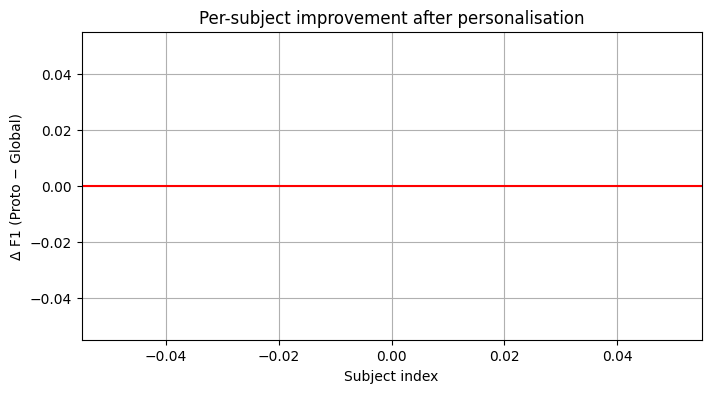

In [18]:
plt.figure(figsize=(8,4))
plt.plot(res["proto_f1"] - res["global_f1"], marker="o", linestyle="none")
plt.axhline(0, color="red")
plt.xlabel("Subject index")
plt.ylabel("Δ F1 (Proto − Global)")
plt.title("Per-subject improvement after personalisation")
plt.grid(True)
plt.show()
